In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from math import sqrt
import xgboost as xgb
from statsmodels.tsa.statespace.sarimax import SARIMAX
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

In [ ]:
csv_path = "data\jena_climate_2009_2016.csv"
df = pd.read_csv(csv_path)

<>:1: SyntaxWarning: invalid escape sequence '\A'
<>:1: SyntaxWarning: invalid escape sequence '\A'
C:\Users\admin\AppData\Local\Temp\ipykernel_40336\2478020969.py:1: SyntaxWarning: invalid escape sequence '\A'
  csv_path = "D:\Applied_Python_Programming_for_Data_Science\Final_Project\data\jena_climate_2009_2016.csv"


In [ ]:
df['wv (m/s)']=df['wv (m/s)'].replace(-9999.00, 0)
df['max. wv (m/s)']=df['max. wv (m/s)'].replace(-9999.00, 0)

wv = df.pop('wv (m/s)')
max_wv = df.pop('max. wv (m/s)')

wd_rad = df.pop('wd (deg)')*np.pi / 180

df['Wx'] = wv*np.cos(wd_rad)
df['Wy'] = wv*np.sin(wd_rad)

df['max Wx'] = max_wv*np.cos(wd_rad)
df['max Wy'] = max_wv*np.sin(wd_rad)

df = df[5::6]

date_time = pd.to_datetime(df.pop('Date Time'), format='%d.%m.%Y %H:%M:%S')

df = df.reset_index()
df = df.drop(columns=['index'])

date_time = date_time.reset_index()
date_time = date_time.drop(columns=['index'])

In [4]:
df.shape

(70091, 15)

In [5]:
date_time.shape

(70091, 1)

In [6]:
target_col = 'T (degC)'
feature_cols = df.columns.drop(target_col)

In [ ]:
split_idx = int(len(df) * 0.7)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

y_train = train_df[target_col]
y_test = test_df[target_col]
X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
def create_sequences(X, y, seq_length=24):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

seq_length = 24
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values, seq_length)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test.values, seq_length)

In [12]:
lstm_model_1 = Sequential([
    LSTM(32, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dense(1)
])
lstm_model_1.compile(optimizer='adam', loss='mse')
lstm_model_1.fit(X_train_seq, y_train_seq, epochs=30, batch_size=64, validation_split=0.1, verbose=2)

y_pred_lstm_1 = lstm_model_1.predict(X_test_seq)
rmse_lstm_1 = sqrt(mean_squared_error(y_test_seq, y_pred_lstm_1))

rmse_lstm_1

Epoch 1/30


c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


690/690 - 12s - 18ms/step - loss: 25.4993 - val_loss: 5.2982
Epoch 2/30
690/690 - 12s - 17ms/step - loss: 2.6845 - val_loss: 1.6928
Epoch 3/30
690/690 - 12s - 17ms/step - loss: 1.1487 - val_loss: 0.9787
Epoch 4/30
690/690 - 12s - 18ms/step - loss: 0.7767 - val_loss: 0.7811
Epoch 5/30
690/690 - 12s - 17ms/step - loss: 0.6441 - val_loss: 0.6711
Epoch 6/30
690/690 - 12s - 18ms/step - loss: 0.5835 - val_loss: 0.6323
Epoch 7/30
690/690 - 13s - 18ms/step - loss: 0.5497 - val_loss: 0.6050
Epoch 8/30
690/690 - 13s - 18ms/step - loss: 0.5261 - val_loss: 0.6063
Epoch 9/30
690/690 - 12s - 18ms/step - loss: 0.5131 - val_loss: 0.5787
Epoch 10/30
690/690 - 13s - 18ms/step - loss: 0.5018 - val_loss: 0.5686
Epoch 11/30
690/690 - 13s - 18ms/step - loss: 0.4970 - val_loss: 0.5713
Epoch 12/30
690/690 - 13s - 18ms/step - loss: 0.4991 - val_loss: 0.5704
Epoch 13/30
690/690 - 12s - 18ms/step - loss: 0.4865 - val_loss: 0.5652
Epoch 14/30
690/690 - 12s - 18ms/step - loss: 0.4798 - val_loss: 0.5746
Epoch 15/30

0.6762003613148931

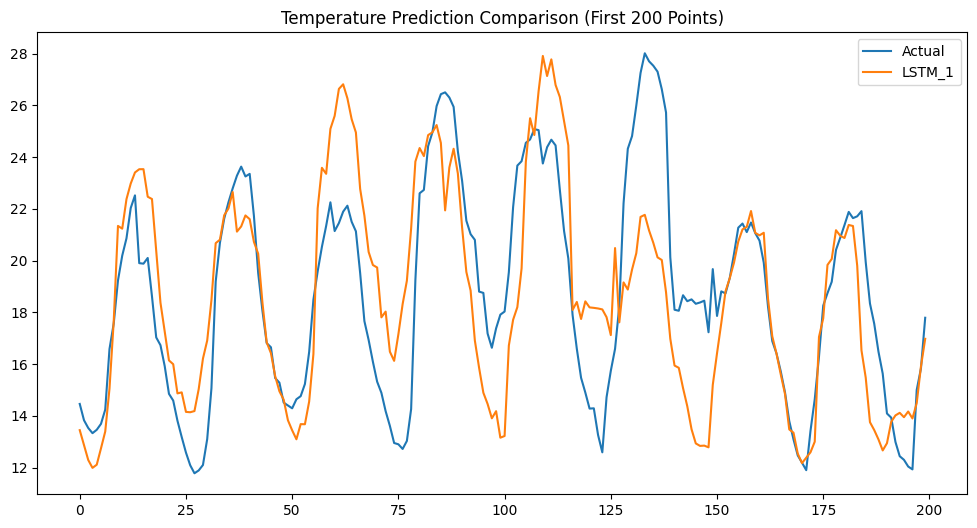

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values[:200], label='Actual')
plt.plot(y_pred_lstm_1[:200], label='LSTM_1')
plt.legend()
plt.title('Temperature Prediction Comparison (First 200 Points)')
plt.show()